Shape: (74682, 4)
     ID        Topic Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                Text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Sentiment Values: ['Positive' 'Neutral' 'Negative' 'Irrelevant']


/tmp/ipykernel_7018/894826193.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df,


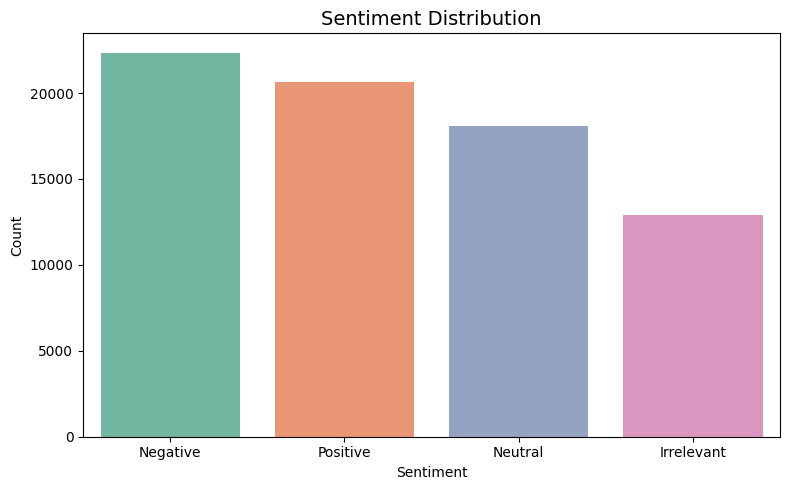

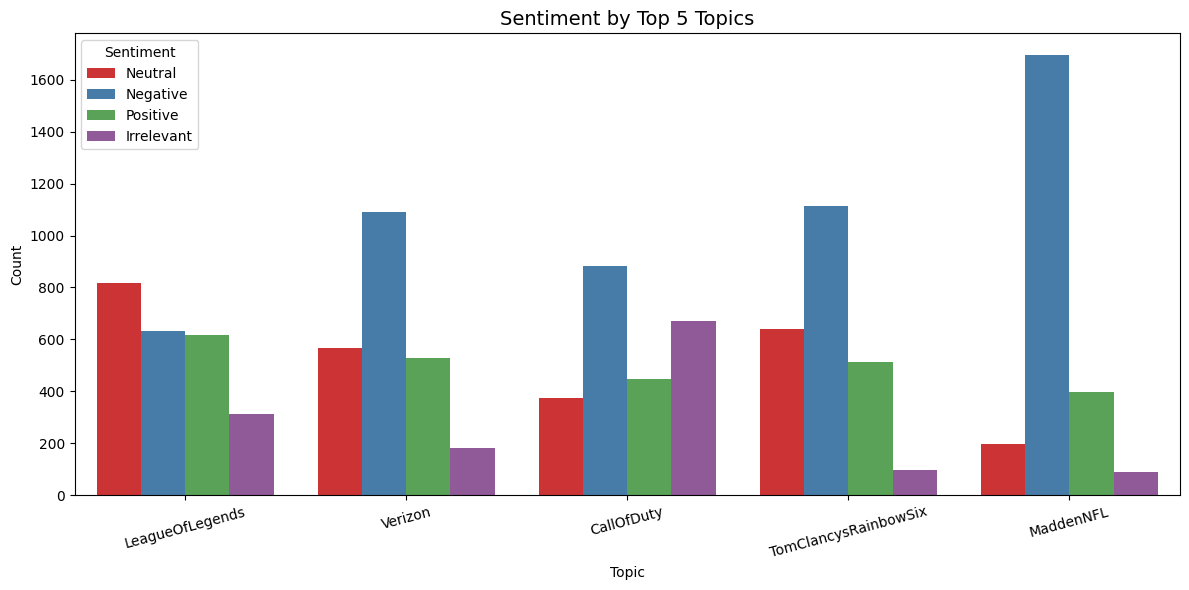

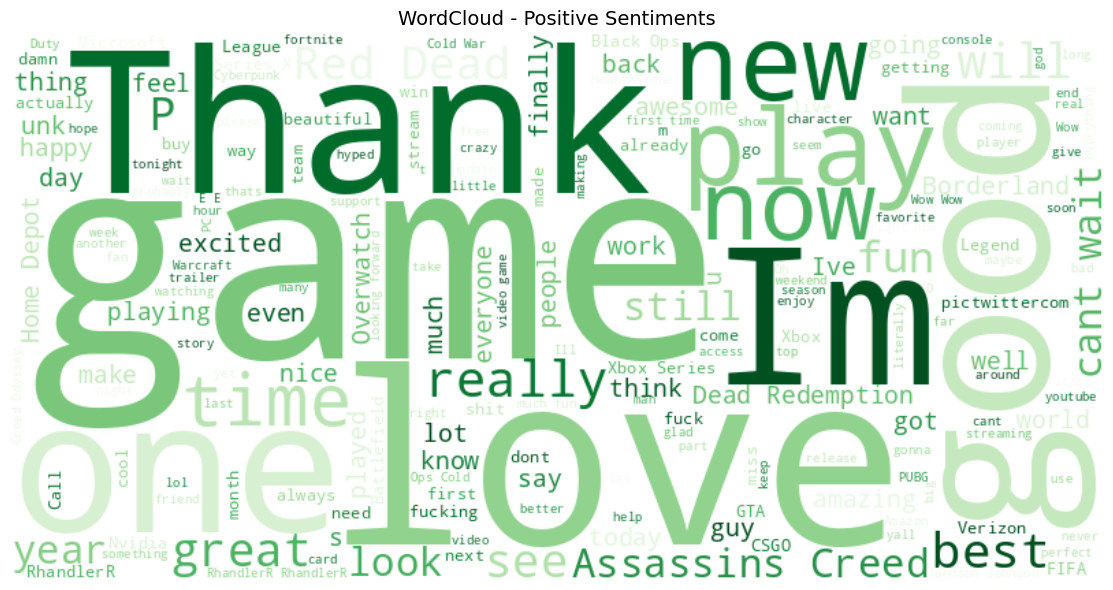

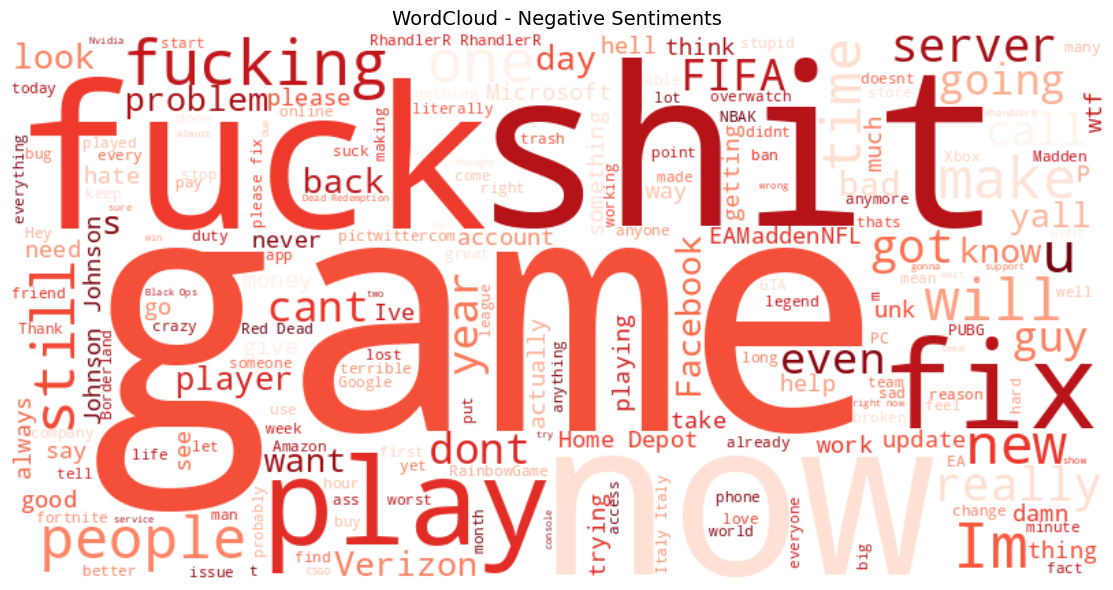

✅ All Task 04 charts saved!


In [1]:
# ============================================================
# PRODIGY INFOTECH - DATA SCIENCE INTERNSHIP
# Task 04: Sentiment Analysis on Social Media Data
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

# ── Load Dataset ──────────────────────────────────────────
df = pd.read_csv('twitter_training.csv', header=None)
df.columns = ['ID', 'Topic', 'Sentiment', 'Text']
print("Shape:", df.shape)
print(df.head())
print("\nSentiment Values:", df['Sentiment'].unique())

# ── Data Cleaning ─────────────────────────────────────────
df = df.dropna(subset=['Text', 'Sentiment'])
df['Text'] = df['Text'].astype(str)

# ── Chart 1: Sentiment Distribution ───────────────────────
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=df,
              order=df['Sentiment'].value_counts().index,
              palette='Set2')
plt.title('Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('Task04_sentiment_distribution.png', dpi=150)
plt.show()

# ── Chart 2: Sentiment by Topic (Top 5 Topics) ────────────
top5_topics = df['Topic'].value_counts().head(5).index
df_top5 = df[df['Topic'].isin(top5_topics)]

plt.figure(figsize=(12, 6))
sns.countplot(x='Topic', hue='Sentiment', data=df_top5, palette='Set1')
plt.title('Sentiment by Top 5 Topics', fontsize=14)
plt.xlabel('Topic')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('Task04_sentiment_by_topic.png', dpi=150)
plt.show()

# ── Chart 3: WordCloud - Positive Sentiments ──────────────
positive_text = ' '.join(df[df['Sentiment'] == 'Positive']['Text'].tolist())
positive_text = re.sub(r'http\S+|@\S+|[^a-zA-Z ]', '', positive_text)

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Greens').generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Positive Sentiments', fontsize=14)
plt.tight_layout()
plt.savefig('Task04_positive_wordcloud.png', dpi=150)
plt.show()

# ── Chart 4: WordCloud - Negative Sentiments ──────────────
negative_text = ' '.join(df[df['Sentiment'] == 'Negative']['Text'].tolist())
negative_text = re.sub(r'http\S+|@\S+|[^a-zA-Z ]', '', negative_text)

wordcloud_neg = WordCloud(width=800, height=400,
                           background_color='white',
                           colormap='Reds').generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Negative Sentiments', fontsize=14)
plt.tight_layout()
plt.savefig('Task04_negative_wordcloud.png', dpi=150)
plt.show()

print("✅ All Task 04 charts saved!")